
# Proposal-aligned right-boundary Rényi-2 Binder calculation

This notebook implements the **right edge of the phase diagram** in the research proposal
*Phases and criticality of nonlinear observables in 1d*.

## Exact phase-diagram parameterization

The model uses

\[
\lambda_x=\delta\lambda,\qquad
\lambda_{zz}=\delta(1-\lambda),\qquad
q_x=q_{zz}=q,
\]

with \(\delta=0.7\). The right edge is therefore

\[
\lambda=1,\qquad
\lambda_x=0.7,\qquad
\lambda_{zz}=0,\qquad
q_x=q_{zz}=q\in[0,1/2].
\]

So the scan variable is **\(q\)**, not \(P_x\) alone. Even though there is no
\(ZZ\) weak measurement on this edge, the \(ZZ\) dephasing channel remains present.

The layer order is

1. weak \(X\) measurements, sampled according to the Born rule;
2. \(X\) dephasing with strength \(q_x=q\);
3. weak \(ZZ\) measurements, absent here because \(\lambda_{zz}=0\);
4. \(ZZ\) dephasing with strength \(q_{zz}=q\).

Open boundary conditions are used by default, matching the computationally efficient
MPS numerics used for most data in the reference model.

## Observable required by the proposal

For each sampled measurement trajectory \(m\),

\[
G_2(i,j;m)=
\frac{
\langle\!\langle\rho_m|
Z_iZ_i'Z_jZ_j'
|\rho_m\rangle\!\rangle
}{
\langle\!\langle\rho_m|\rho_m\rangle\!\rangle
},
\]

\[
G_2^{(4)}(i,j,k,\ell;m)=
\frac{
\langle\!\langle\rho_m|
Z_iZ_i'Z_jZ_j'Z_kZ_k'Z_\ell Z_\ell'
|\rho_m\rangle\!\rangle
}{
\langle\!\langle\rho_m|\rho_m\rangle\!\rangle
},
\]

and

\[
B_2(m)=
1-
\frac{\sum_{i,j,k,\ell}G_2^{(4)}(i,j,k,\ell;m)}
{3\left(\sum_{i,j}G_2(i,j;m)\right)^2}.
\]

Because trajectories are sampled using their conditional Born probabilities, the
proposal observable is the ordinary sample mean

\[
\overline{B_2}=\frac1{N_{\rm trials}}\sum_m B_2(m).
\]

The ratio constructed from separately averaged \(M_2\) and \(M_4\) is retained only
as a diagnostic and is **not** used as the main result.

## Scope within the proposal

This notebook addresses:

- roadmap item 1: test whether \(B_2\) curves cross when decoherence is present;
- the \(B_2\) part of roadmap item 2: locate the strong-to-weak boundary;
- the first stage of item 3: prepare finite-size crossing and scaling-collapse data.

A separate reference-qubit calculation is needed to compare this boundary with
the reference entropy \(S_R\).


In [2]:

import Pkg

# Uncomment once if packages are missing:
# Pkg.add(["ITensors", "ITensorMPS", "DataFrames", "CSV", "Plots"])

using Random
using Statistics
using LinearAlgebra
using Printf
using Dates
using Test

using ITensors
using ITensorMPS
using DataFrames
using CSV
using Plots

println("Julia threads: ", Threads.nthreads())


Julia threads: 10



## Reproducible configuration

The initial state is

\[
\rho_0=|\uparrow\cdots\uparrow\rangle
\langle\uparrow\cdots\uparrow|,
\]

which lies in the repetition-code space. The observable is evaluated at the end
of a complete layer, after both dephasing channels.

The production result must be checked against:

- longer evolution time \(T\);
- larger MPS bond dimension;
- tighter truncation cutoff;
- more Born-sampled trajectories;
- a finer \(q\) grid around the crossing.


In [3]:

# ============================================================
# Proposal parameters and numerical defaults
# ============================================================

DELTA = 0.7
RIGHT_LAMBDA = 1.0

DYN_MAXDIM = 256
DYN_CUTOFF = 1e-12
OBS_MAXDIM_FACTOR = 4
OBS_CUTOFF = 1e-14

BOUNDARY = :open
@assert BOUNDARY in (:open,)

RUN_QUICK_SCAN = true
RUN_PRODUCTION_SCAN = false

function proposal_parameters(lambda::Real, q::Real; delta::Real=DELTA)
    @assert 0.0 <= lambda <= 1.0
    @assert 0.0 <= q <= 0.5
    @assert 0.0 < delta < 1.0

    return (
        lambda=Float64(lambda),
        delta=Float64(delta),
        lambda_x=Float64(delta * lambda),
        lambda_zz=Float64(delta * (1 - lambda)),
        q=Float64(q),
        q_x=Float64(q),
        q_zz=Float64(q),
    )
end

right_edge_parameters(q::Real) =
    proposal_parameters(RIGHT_LAMBDA, q; delta=DELTA)

@show right_edge_parameters(0.10)


right_edge_parameters(0.1) = (lambda = 1.0, delta = 0.7, lambda_x = 0.7, lambda_zz = 0.0, q = 0.1, q_x = 0.1, q_zz = 0.1)


(lambda = 1.0, delta = 0.7, lambda_x = 0.7, lambda_zz = 0.0, q = 0.1, q_x = 0.1, q_zz = 0.1)

In [4]:

# ============================================================
# Doubled-MPS utilities
# ============================================================

const sigma_x = Float64[0 1; 1 0]
const sigma_z = Float64[1 0; 0 -1]
const identity_2 = Matrix{Float64}(I, 2, 2)

function pair_mps(local_vec::AbstractVector, s_bra::Index, s_ket::Index)
    @assert length(local_vec) == 4
    return MPS(collect(local_vec), [s_bra, s_ket])
end

function product_density_mps(sites_in, local_vec::AbstractVector)
    sites = collect(sites_in)
    @assert iseven(length(sites))

    tensors = ITensor[]
    for n in 1:2:length(sites)
        pair = pair_mps(local_vec, sites[n], sites[n + 1])
        push!(tensors, pair[1], pair[2])
    end
    return MPS(tensors)
end

function bell_state(sites_in)
    # |I>> = product_i (|00> + |11>)
    return product_density_mps(
        collect(sites_in),
        [1.0, 0.0, 0.0, 1.0],
    )
end

function initial_repetition_code_state(sites_in)
    # |up ... up><up ... up|, a valid state in the repetition-code space.
    return product_density_mps(
        collect(sites_in),
        [1.0, 0.0, 0.0, 0.0],
    )
end

doubled_trace(rho::MPS, trace_bra::MPS) =
    real(inner(trace_bra, rho))

hilbert_schmidt_norm(rho::MPS) =
    real(inner(rho, rho))

function trace_normalize(
    rho::MPS,
    trace_bra::MPS;
    atol::Float64=1e-13,
)
    tr_rho = doubled_trace(rho, trace_bra)

    if !isfinite(tr_rho) || tr_rho <= atol
        error("Invalid density-matrix trace: Tr(rho) = $tr_rho")
    end

    return rho / tr_rho
end

function physical_bonds(L::Int; boundary::Symbol=BOUNDARY)
    @assert L >= 2
    boundary == :open || error("This notebook currently supports :open only.")
    return [(i, i + 1) for i in 1:(L - 1)]
end

function bond_dimension_or_one(rho::MPS, bond::Int)
    link = linkind(rho, bond)

    # ITensor returns `nothing` when two neighboring MPS tensors have no
    # explicit link Index. That represents a tensor-product bond and must
    # be interpreted as bond dimension 1.
    return isnothing(link) ? 1 : dim(link)
end

function max_interphysical_linkdim(rho::MPS, L::Int)
    L <= 1 && return 1

    return maximum(
        bond_dimension_or_one(rho, 2i)
        for i in 1:(L - 1)
    )
end


max_interphysical_linkdim (generic function with 1 method)


## Weak \(X\) measurements: exact Born sampling

For

\[
K_m^{X}=
\frac{I+(-1)^m\lambda_x X}
{\sqrt{2(1+\lambda_x^2)}},
\]

the code constructs both unnormalized post-measurement density matrices,
uses their traces as the two Born weights, samples one outcome, and then
normalizes the selected state.

This avoids assuming equal outcome probabilities.


In [5]:

# ============================================================
# Weak X measurement with exact Born sampling
# ============================================================

function x_measurement_candidates(
    rho::MPS,
    sites,
    i::Int,
    lambda_x::Float64,
    trace_bra::MPS;
    maxdim::Int,
    cutoff::Float64,
    negative_weight_tol::Float64=1e-10,
    completeness_warn_tol::Float64=5e-8,
    completeness_fail_tol::Float64=1e-6,
)
    @assert 0.0 <= lambda_x <= 1.0

    bra_i = 2i - 1
    ket_i = 2i

    states = Vector{MPS}(undef, 2)
    weights = zeros(Float64, 2)

    for outcome in 0:1
        K = (
            identity_2 + (-1)^outcome * lambda_x * sigma_x
        ) / sqrt(2 * (1 + lambda_x^2))

        # Vectorized action: K rho K^dagger -> K on one layer and K* on the other.
        #
        # Important: keep these as two one-site gates. Multiplying them into
        # one two-site ITensor forces an unnecessary two-site SVD and can
        # introduce branch-dependent truncation errors into the Born weights.
        K_bra = op(K, sites[bra_i])
        K_ket = op(conj(K), sites[ket_i])

        rho_m = apply(
            [K_bra, K_ket],
            rho;
            cutoff=cutoff,
            maxdim=maxdim,
        )

        weight = doubled_trace(rho_m, trace_bra)

        if !isfinite(weight) || weight < -negative_weight_tol
            error(
                "Invalid Born weight at site $i, outcome $outcome: $weight. " *
                "Increase maxdim or reduce cutoff."
            )
        end

        states[outcome + 1] = rho_m
        weights[outcome + 1] = max(weight, 0.0)
    end

    total_weight = sum(weights)
    input_trace = doubled_trace(rho, trace_bra)

    if total_weight <= negative_weight_tol
        error("Both X-measurement outcomes have zero numerical weight.")
    end

    completeness_error = abs(total_weight - input_trace)
    relative_error = completeness_error / max(abs(input_trace), eps(Float64))

    # The two post-measurement MPS branches are compressed independently.
    # Therefore their approximate traces need not add to Tr(rho) to machine
    # precision. Normalize the two nonnegative weights by their computed sum.
    # Only stop when the drift is large enough to indicate failed convergence.
    if relative_error > completeness_fail_tol
        error(
            "Kraus completeness drift is too large: " *
            "sum(weights)=$total_weight, Tr(rho)=$input_trace, " *
            "relative_error=$relative_error. Increase maxdim and/or " *
            "decrease cutoff."
        )
    elseif relative_error > completeness_warn_tol
        @warn(
            "Small Kraus completeness drift from MPS truncation",
            site=i,
            relative_error=relative_error,
            maxdim=maxdim,
            cutoff=cutoff,
        )
    end

    return states, weights ./ total_weight
end

function apply_weak_x_measurement_site(
    rho::MPS,
    sites,
    i::Int,
    lambda_x::Float64,
    trace_bra::MPS,
    rng::AbstractRNG;
    maxdim::Int,
    cutoff::Float64,
)
    states, probabilities = x_measurement_candidates(
        rho,
        sites,
        i,
        lambda_x,
        trace_bra;
        maxdim=maxdim,
        cutoff=cutoff,
    )

    selected = rand(rng) < probabilities[1] ? 1 : 2
    rho_selected = states[selected]

    return (
        trace_normalize(rho_selected, trace_bra),
        selected - 1,
        probabilities,
    )
end

function apply_weak_x_layer(
    rho::MPS,
    sites,
    L::Int,
    lambda_x::Float64,
    trace_bra::MPS,
    rng::AbstractRNG;
    maxdim::Int,
    cutoff::Float64,
)
    outcomes = Vector{Int}(undef, L)

    for i in 1:L
        rho, outcomes[i], _ = apply_weak_x_measurement_site(
            rho,
            sites,
            i,
            lambda_x,
            trace_bra,
            rng;
            maxdim=maxdim,
            cutoff=cutoff,
        )
    end

    return rho, outcomes
end


apply_weak_x_layer (generic function with 1 method)


## Both dephasing channels remain on the right edge

The right edge has \(\lambda_{zz}=0\), so the weak \(ZZ\) measurement layer is
absent. It does **not** imply \(q_{zz}=0\).

The proposal slice requires

\[
q_x=q_{zz}=q,
\]

with

\[
\mathcal N_i^x(\rho)=(1-q)\rho+qX_i\rho X_i,
\]

\[
\mathcal N_i^{zz}(\rho)=(1-q)\rho+
qZ_iZ_{i+1}\rho Z_iZ_{i+1}.
\]


In [6]:

# ============================================================
# X and ZZ dephasing superoperator gates
# ============================================================

function build_x_dephasing_gates(sites, L::Int, q_x::Float64)
    @assert 0.0 <= q_x <= 0.5

    gates = Vector{ITensor}(undef, L)

    for i in 1:L
        bra_i = 2i - 1
        ket_i = 2i

        identity_gate =
            op(identity_2, sites[bra_i]) *
            op(conj(identity_2), sites[ket_i])

        flip_gate =
            op(sigma_x, sites[bra_i]) *
            op(conj(sigma_x), sites[ket_i])

        gates[i] =
            (1 - q_x) * identity_gate +
            q_x * flip_gate
    end

    return gates
end

function build_zz_dephasing_gates(
    sites,
    L::Int,
    q_zz::Float64;
    boundary::Symbol=BOUNDARY,
)
    @assert 0.0 <= q_zz <= 0.5

    bonds = physical_bonds(L; boundary=boundary)
    gates = Vector{ITensor}(undef, length(bonds))

    for (n, (i, j)) in enumerate(bonds)
        bra_i, ket_i = 2i - 1, 2i
        bra_j, ket_j = 2j - 1, 2j

        identity_gate =
            op(identity_2, sites[bra_i]) *
            op(identity_2, sites[bra_j]) *
            op(conj(identity_2), sites[ket_i]) *
            op(conj(identity_2), sites[ket_j])

        zz_gate =
            op(sigma_z, sites[bra_i]) *
            op(sigma_z, sites[bra_j]) *
            op(conj(sigma_z), sites[ket_i]) *
            op(conj(sigma_z), sites[ket_j])

        gates[n] =
            (1 - q_zz) * identity_gate +
            q_zz * zz_gate
    end

    return gates
end

function apply_channel_layer(
    rho::MPS,
    gates::Vector{ITensor},
    trace_bra::MPS;
    maxdim::Int,
    cutoff::Float64,
)
    for gate in gates
        rho = apply(
            [gate],
            rho;
            cutoff=cutoff,
            maxdim=maxdim,
        )
    end

    # The exact channel preserves trace; this removes truncation drift only.
    return trace_normalize(rho, trace_bra)
end


apply_channel_layer (generic function with 1 method)

In [7]:

# ============================================================
# One Born-sampled right-edge trajectory
# ============================================================

function evolve_right_edge_one_trial(
    L::Int;
    q::Float64,
    T_max::Int=4L,
    maxdim::Int=DYN_MAXDIM,
    cutoff::Float64=DYN_CUTOFF,
    seed::Union{Nothing,Int}=nothing,
    rng::AbstractRNG=isnothing(seed) ?
        Random.default_rng() : MersenneTwister(seed),
    boundary::Symbol=BOUNDARY,
)
    @assert L >= 2
    @assert 0.0 <= q <= 0.5
    @assert T_max >= 0

    params = right_edge_parameters(q)

    # Proposal-alignment assertions.
    @assert isapprox(params.lambda_x, 0.7; atol=1e-14)
    @assert isapprox(params.lambda_zz, 0.0; atol=1e-14)
    @assert params.q_x == params.q_zz && params.q_zz == params.q

    sites = siteinds("Qubit", 2L)
    trace_bra = bell_state(sites)
    rho = trace_normalize(
        initial_repetition_code_state(sites),
        trace_bra,
    )

    x_dephasing_gates =
        build_x_dephasing_gates(sites, L, params.q_x)

    zz_dephasing_gates =
        build_zz_dephasing_gates(
            sites,
            L,
            params.q_zz;
            boundary=boundary,
        )

    max_trace_error =
        abs(doubled_trace(rho, trace_bra) - 1.0)

    max_cross_site_bond =
        max_interphysical_linkdim(rho, L)

    for _ in 1:T_max
        # 1. Weak X measurements.
        rho, _ = apply_weak_x_layer(
            rho,
            sites,
            L,
            params.lambda_x,
            trace_bra,
            rng;
            maxdim=maxdim,
            cutoff=cutoff,
        )

        # 2. X dephasing, q_x = q.
        rho = apply_channel_layer(
            rho,
            x_dephasing_gates,
            trace_bra;
            maxdim=maxdim,
            cutoff=cutoff,
        )

        # 3. Weak ZZ measurements are absent because lambda_zz = 0.

        # 4. ZZ dephasing remains present, q_zz = q.
        rho = apply_channel_layer(
            rho,
            zz_dephasing_gates,
            trace_bra;
            maxdim=maxdim,
            cutoff=cutoff,
        )

        max_trace_error = max(
            max_trace_error,
            abs(doubled_trace(rho, trace_bra) - 1.0),
        )

        max_cross_site_bond = max(
            max_cross_site_bond,
            max_interphysical_linkdim(rho, L),
        )
    end

    return (
        rho=rho,
        sites=sites,
        trace_bra=trace_bra,
        params=params,
        boundary=boundary,
        max_trace_error=max_trace_error,
        max_interphysical_linkdim=max_cross_site_bond,
    )
end


evolve_right_edge_one_trial (generic function with 1 method)


## Proposal \(B_2(m)\): replica-overlap order parameter only

Define

\[
q_i=Z_iZ_i',\qquad Q=\sum_{i=1}^{L}q_i.
\]

Because the \(q_i\) commute and \(q_i^2=I\),

\[
M_2(m)=
\frac{\langle\!\langle\rho_m|Q^2|\rho_m\rangle\!\rangle}
{L^2\langle\!\langle\rho_m|\rho_m\rangle\!\rangle}
=
\frac1{L^2}\sum_{i,j}G_2(i,j;m),
\]

\[
M_4(m)=
\frac{\langle\!\langle\rho_m|Q^4|\rho_m\rangle\!\rangle}
{L^4\langle\!\langle\rho_m|\rho_m\rangle\!\rangle}
=
\frac1{L^4}\sum_{i,j,k,\ell}G_2^{(4)}(i,j,k,\ell;m).
\]

Therefore,

\[
B_2(m)=1-\frac{M_4(m)}{3M_2(m)^2}.
\]

No bra-only magnetization observable is used in this notebook.


In [8]:

# ============================================================
# Proposal Rényi-2 moments and Binder
# ============================================================

function build_replica_overlap_mpo(sites, L::Int)
    os = OpSum()

    for i in 1:L
        os += 1.0, "Z", 2i - 1, "Z", 2i
    end

    return MPO(os, sites)
end

function binder_from_moments(
    M2::Real,
    M4::Real;
    tol::Float64=1e-13,
)
    if !isfinite(M2) || !isfinite(M4) || M2 <= tol
        return NaN
    end

    return 1.0 - M4 / (3.0 * M2^2)
end

function renyi2_binder_one_trajectory(
    rho::MPS,
    sites,
    L::Int;
    maxdim::Int=OBS_MAXDIM_FACTOR * DYN_MAXDIM,
    cutoff::Float64=OBS_CUTOFF,
    norm_tol::Float64=1e-14,
)
    Q = build_replica_overlap_mpo(sites, L)

    hs_norm = hilbert_schmidt_norm(rho)

    if !isfinite(hs_norm) || hs_norm <= norm_tol
        error("Invalid doubled-state norm: <rho|rho> = $hs_norm")
    end

    psi1 = apply(
        Q,
        rho;
        cutoff=cutoff,
        maxdim=maxdim,
    )

    psi2 = apply(
        Q,
        psi1;
        cutoff=cutoff,
        maxdim=maxdim,
    )

    numerator_2 = real(inner(psi1, psi1))
    numerator_4 = real(inner(psi2, psi2))

    M2 = numerator_2 / (L^2 * hs_norm)
    M4 = numerator_4 / (L^4 * hs_norm)
    B2 = binder_from_moments(M2, M4)

    return (
        M2=M2,
        M4=M4,
        B2=B2,
        purity=hs_norm,
        numerator_2=numerator_2,
        numerator_4=numerator_4,
    )
end


renyi2_binder_one_trajectory (generic function with 1 method)

In [9]:

# ============================================================
# Independent direct-correlator implementation for validation
# ============================================================

function replica_z_gates(sites, L::Int)
    return [
        op(sigma_z, sites[2i - 1]) *
        op(sigma_z, sites[2i])
        for i in 1:L
    ]
end

function renyi2_string_expectation(
    rho::MPS,
    q_gates::Vector{ITensor},
    active_sites::Vector{Int},
    hs_norm::Float64;
    maxdim::Int,
    cutoff::Float64,
)
    isempty(active_sites) && return 1.0

    gates = ITensor[q_gates[i] for i in active_sites]

    rho_O = apply(
        gates,
        rho;
        cutoff=cutoff,
        maxdim=maxdim,
    )

    return real(inner(rho, rho_O) / hs_norm)
end

function renyi2_moments_direct(
    rho::MPS,
    sites,
    L::Int;
    maxdim::Int=1024,
    cutoff::Float64=1e-14,
)
    hs_norm = hilbert_schmidt_norm(rho)
    hs_norm > 1e-14 || error("Doubled-state norm is too small.")

    q_gates = replica_z_gates(sites, L)

    pair_sum = 0.0
    for i in 1:(L - 1)
        for j in (i + 1):L
            pair_sum += renyi2_string_expectation(
                rho,
                q_gates,
                [i, j],
                hs_norm;
                maxdim=maxdim,
                cutoff=cutoff,
            )
        end
    end

    quad_sum = 0.0
    if L >= 4
        for i in 1:(L - 3)
            for j in (i + 1):(L - 2)
                for k in (j + 1):(L - 1)
                    for ell in (k + 1):L
                        quad_sum += renyi2_string_expectation(
                            rho,
                            q_gates,
                            [i, j, k, ell],
                            hs_norm;
                            maxdim=maxdim,
                            cutoff=cutoff,
                        )
                    end
                end
            end
        end
    end

    # Exact multiplicities from q_i^2 = I.
    M2 = (L + 2 * pair_sum) / L^2

    identity_count_4 = 3L^2 - 2L
    pair_coefficient_4 = 12L - 16

    M4 = (
        identity_count_4 +
        pair_coefficient_4 * pair_sum +
        24 * quad_sum
    ) / L^4

    return (
        M2=M2,
        M4=M4,
        B2=binder_from_moments(M2, M4),
        purity=hs_norm,
        pair_sum=pair_sum,
        quad_sum=quad_sum,
    )
end


renyi2_moments_direct (generic function with 1 method)


## Exact and structural sanity checks

Expected limits for the proposal \(B_2\):

- all-up pure state: \(B_2=2/3\);
- \(X\)-polarized pure product state: \(B_2=2/(3L)\);
- maximally mixed state: \(B_2=2/3\).

The last result is not a bug: the Rényi-2 order parameter measures locking between
the two doubled-state copies.

The tests also verify:

- the MPO and direct-correlator implementations agree;
- weak-measurement Born probabilities are correct;
- both dephasing layers preserve trace;
- \(q_x=q_{zz}=q\) is actually used.


In [10]:

# ============================================================
# Sanity checks
# ============================================================

function simple_density_state(sites; state::Symbol)
    if state == :up
        local_vec = [1.0, 0.0, 0.0, 0.0]
    elseif state == :plus_x
        local_vec = [0.5, 0.5, 0.5, 0.5]
    elseif state == :maximally_mixed
        local_vec = [0.5, 0.0, 0.0, 0.5]
    else
        error("Unknown state: $state")
    end

    return product_density_mps(sites, local_vec)
end

function run_sanity_checks(; L::Int=4)
    sites = siteinds("Qubit", 2L)
    trace_bra = bell_state(sites)

    rho_up = trace_normalize(
        simple_density_state(sites; state=:up),
        trace_bra,
    )

    rho_plus = trace_normalize(
        simple_density_state(sites; state=:plus_x),
        trace_bra,
    )

    rho_mix = trace_normalize(
        simple_density_state(sites; state=:maximally_mixed),
        trace_bra,
    )

    finite_size_disordered = 2 / (3L)

    up = renyi2_binder_one_trajectory(
        rho_up,
        sites,
        L;
        maxdim=1024,
        cutoff=1e-14,
    )

    plus = renyi2_binder_one_trajectory(
        rho_plus,
        sites,
        L;
        maxdim=1024,
        cutoff=1e-14,
    )

    mix = renyi2_binder_one_trajectory(
        rho_mix,
        sites,
        L;
        maxdim=1024,
        cutoff=1e-14,
    )

    @test isapprox(up.B2, 2 / 3; atol=1e-9, rtol=1e-9)
    @test isapprox(
        plus.B2,
        finite_size_disordered;
        atol=1e-9,
        rtol=1e-9,
    )
    @test isapprox(mix.B2, 2 / 3; atol=1e-9, rtol=1e-9)

    direct_up = renyi2_moments_direct(
        rho_up,
        sites,
        L;
        maxdim=1024,
        cutoff=1e-14,
    )

    direct_plus = renyi2_moments_direct(
        rho_plus,
        sites,
        L;
        maxdim=1024,
        cutoff=1e-14,
    )

    @test isapprox(up.M2, direct_up.M2; atol=1e-9, rtol=1e-9)
    @test isapprox(up.M4, direct_up.M4; atol=1e-9, rtol=1e-9)
    @test isapprox(plus.M2, direct_plus.M2; atol=1e-9, rtol=1e-9)
    @test isapprox(plus.M4, direct_plus.M4; atol=1e-9, rtol=1e-9)

    # At lambda_x=1, |up> has <X>=0 and therefore equal outcomes.
    _, up_probabilities = x_measurement_candidates(
        rho_up,
        sites,
        1,
        1.0,
        trace_bra;
        maxdim=256,
        cutoff=1e-14,
    )

    # |+x> must give the + outcome with probability one.
    _, plus_probabilities = x_measurement_candidates(
        rho_plus,
        sites,
        1,
        1.0,
        trace_bra;
        maxdim=256,
        cutoff=1e-14,
    )

    @test isapprox(up_probabilities[1], 0.5; atol=1e-10)
    @test isapprox(up_probabilities[2], 0.5; atol=1e-10)
    @test isapprox(plus_probabilities[1], 1.0; atol=1e-10)
    @test isapprox(plus_probabilities[2], 0.0; atol=1e-10)

    q_test = 0.17
    params = right_edge_parameters(q_test)
    @test params.q_x == q_test
    @test params.q_zz == q_test
    @test params.lambda_x == 0.7
    @test params.lambda_zz == 0.0

    x_gates = build_x_dephasing_gates(sites, L, q_test)
    zz_gates = build_zz_dephasing_gates(sites, L, q_test)

    rho_channel = apply_channel_layer(
        rho_up,
        x_gates,
        trace_bra;
        maxdim=256,
        cutoff=1e-14,
    )

    rho_channel = apply_channel_layer(
        rho_channel,
        zz_gates,
        trace_bra;
        maxdim=256,
        cutoff=1e-14,
    )

    @test isapprox(
        doubled_trace(rho_channel, trace_bra),
        1.0;
        atol=1e-10,
    )

    println("B2(all-up)           = ", up.B2)
    println("B2(+x product)       = ", plus.B2)
    println("B2(maximally mixed)  = ", mix.B2)
    println("Born probabilities, up = ", up_probabilities)
    println("Born probabilities, +x = ", plus_probabilities)
    println("All proposal-alignment sanity checks passed.")
end

run_sanity_checks()


B2(all-up)           = 0.6666666666666667
B2(+x product)       = 0.16666666666666508
B2(maximally mixed)  = 0.6666666666666667
Born probabilities, up = [0.5, 0.5]
Born probabilities, +x = [1.0, 0.0]
All proposal-alignment sanity checks passed.



## Born-rule trajectory average

The proposal defines \(B_2(m)\) first and then averages the observable over
measurement trajectories. Accordingly, the primary estimate below is

\[
\overline{B_2}=\operatorname{mean}\{B_2(m)\}.
\]

The bootstrap resamples the list of trajectory-level \(B_2(m)\) values directly.

For transparency, the notebook also reports

\[
1-\frac{\overline{M_4}}{3\overline{M_2}^{\,2}},
\]

under the name `B2_ratio_of_mean_moments`. It is generally different and is not
the proposal observable.


In [11]:

# ============================================================
# Bootstrap of the proposal trajectory average
# ============================================================

function bootstrap_mean(
    values::AbstractVector;
    nboot::Int=1000,
    rng::AbstractRNG=MersenneTwister(1234),
)
    finite_values = collect(filter(isfinite, values))
    n = length(finite_values)

    n >= 2 || error("At least two finite values are required.")

    samples = Vector{Float64}(undef, nboot)

    for b in 1:nboot
        indices = rand(rng, 1:n, n)
        samples[b] = mean(finite_values[indices])
    end

    return (
        standard_error=std(samples; corrected=true),
        ci_low=quantile(samples, 0.025),
        ci_high=quantile(samples, 0.975),
        samples=samples,
    )
end


bootstrap_mean (generic function with 1 method)

In [12]:

# ============================================================
# One right-edge parameter point
# ============================================================

function run_right_edge_point(
    L::Int,
    q::Float64;
    ntrials::Int=100,
    T_max::Int=4L,
    maxdim::Int=DYN_MAXDIM,
    cutoff::Float64=DYN_CUTOFF,
    obs_maxdim::Int=OBS_MAXDIM_FACTOR * maxdim,
    obs_cutoff::Float64=OBS_CUTOFF,
    seed::Int=1234,
    nboot::Int=1000,
    boundary::Symbol=BOUNDARY,
)
    @assert ntrials >= 2
    @assert 0.0 <= q <= 0.5

    master_rng = MersenneTwister(seed)

    M2s = Vector{Float64}(undef, ntrials)
    M4s = Vector{Float64}(undef, ntrials)
    B2s = Vector{Float64}(undef, ntrials)
    purities = Vector{Float64}(undef, ntrials)
    cross_site_dims = Vector{Int}(undef, ntrials)
    trace_errors = Vector{Float64}(undef, ntrials)
    trial_seeds = Vector{Int}(undef, ntrials)

    for trial in 1:ntrials
        trial_seed = Int(rand(master_rng, UInt32))
        trial_seeds[trial] = trial_seed

        evolved = evolve_right_edge_one_trial(
            L;
            q=q,
            T_max=T_max,
            maxdim=maxdim,
            cutoff=cutoff,
            seed=trial_seed,
            boundary=boundary,
        )

        observable = renyi2_binder_one_trajectory(
            evolved.rho,
            evolved.sites,
            L;
            maxdim=obs_maxdim,
            cutoff=obs_cutoff,
        )

        M2s[trial] = observable.M2
        M4s[trial] = observable.M4
        B2s[trial] = observable.B2
        purities[trial] = observable.purity
        cross_site_dims[trial] =
            evolved.max_interphysical_linkdim
        trace_errors[trial] =
            evolved.max_trace_error
    end

    valid = [
        isfinite(M2s[i]) &&
        isfinite(M4s[i]) &&
        isfinite(B2s[i]) &&
        isfinite(purities[i]) &&
        M2s[i] > 0 &&
        purities[i] > 0
        for i in eachindex(B2s)
    ]

    n_valid = count(valid)
    n_valid >= 2 ||
        error("Fewer than two valid trials at L=$L, q=$q.")

    valid_M2 = M2s[valid]
    valid_M4 = M4s[valid]
    valid_B2 = B2s[valid]
    valid_purity = purities[valid]

    # This is the proposal observable.
    B2_mean = mean(valid_B2)

    bootstrap = bootstrap_mean(
        valid_B2;
        nboot=nboot,
        rng=MersenneTwister(seed + 918273),
    )

    # Diagnostic only; not the proposal average.
    M2_mean = mean(valid_M2)
    M4_mean = mean(valid_M4)
    B2_ratio_of_mean_moments =
        binder_from_moments(M2_mean, M4_mean)

    params = right_edge_parameters(q)

    summary = (
        L=L,
        lambda=params.lambda,
        delta=params.delta,
        lambda_x=params.lambda_x,
        lambda_zz=params.lambda_zz,
        q=q,
        q_x=params.q_x,
        q_zz=params.q_zz,
        boundary=string(boundary),
        T_max=T_max,
        ntrials=ntrials,
        n_valid=n_valid,
        seed=seed,
        maxdim=maxdim,
        cutoff=cutoff,
        obs_maxdim=obs_maxdim,
        obs_cutoff=obs_cutoff,
        B2=B2_mean,
        B2_bootstrap_se=bootstrap.standard_error,
        B2_ci_low=bootstrap.ci_low,
        B2_ci_high=bootstrap.ci_high,
        B2_trial_std=std(valid_B2; corrected=true),
        B2_ratio_of_mean_moments=B2_ratio_of_mean_moments,
        M2_mean=M2_mean,
        M4_mean=M4_mean,
        purity_mean=mean(valid_purity),
        purity_std=std(valid_purity; corrected=true),
        max_interphysical_linkdim=maximum(cross_site_dims),
        max_trace_error=maximum(trace_errors),
    )

    trial_table = DataFrame(
        L=fill(L, ntrials),
        q=fill(q, ntrials),
        trial=collect(1:ntrials),
        trial_seed=trial_seeds,
        valid=valid,
        M2=M2s,
        M4=M4s,
        B2=B2s,
        purity=purities,
        max_interphysical_linkdim=cross_site_dims,
        max_trace_error=trace_errors,
    )

    return (
        summary=summary,
        trials=trial_table,
        bootstrap_samples=bootstrap.samples,
    )
end


run_right_edge_point (generic function with 1 method)

In [13]:

# ============================================================
# Scan the right edge: lambda=1, q in [0, 1/2]
# ============================================================

function scan_right_edge(
    L_values,
    q_values;
    ntrials::Int=100,
    T_max_factor::Int=4,
    maxdim::Int=DYN_MAXDIM,
    cutoff::Float64=DYN_CUTOFF,
    obs_maxdim_factor::Int=OBS_MAXDIM_FACTOR,
    obs_cutoff::Float64=OBS_CUTOFF,
    seed::Int=20260709,
    nboot::Int=1000,
    boundary::Symbol=BOUNDARY,
    verbose::Bool=true,
)
    @assert all((0.0 .<= q_values) .& (q_values .<= 0.5))

    summary_rows = NamedTuple[]
    trial_tables = DataFrame[]

    point_index = 0
    total_points = length(L_values) * length(q_values)

    for L in L_values
        for q_value in q_values
            point_index += 1
            q = Float64(q_value)
            point_seed =
                seed + 100_000 * L + 1_000 * point_index

            verbose && @printf(
                "[%d/%d] L=%d, q=%.5f, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q\n",
                point_index,
                total_points,
                L,
                q,
            )

            result = run_right_edge_point(
                L,
                q;
                ntrials=ntrials,
                T_max=T_max_factor * L,
                maxdim=maxdim,
                cutoff=cutoff,
                obs_maxdim=obs_maxdim_factor * maxdim,
                obs_cutoff=obs_cutoff,
                seed=point_seed,
                nboot=nboot,
                boundary=boundary,
            )

            push!(summary_rows, result.summary)
            push!(trial_tables, result.trials)
        end
    end

    return (
        summary=DataFrame(summary_rows),
        trials=isempty(trial_tables) ?
            DataFrame() : vcat(trial_tables...),
    )
end


scan_right_edge (generic function with 1 method)

In [14]:

# ============================================================
# Quick and production configurations
# ============================================================

empty_scan = (
    summary=DataFrame(),
    trials=DataFrame(),
)

quick_scan = empty_scan

if RUN_QUICK_SCAN
    quick_scan = scan_right_edge(
        [4, 6],
        collect(0.0:0.10:0.50);
        ntrials=8,
        T_max_factor=2,
        maxdim=128,
        cutoff=1e-12,
        obs_maxdim_factor=4,
        obs_cutoff=1e-13,
        seed=11071,
        nboot=300,
        verbose=true,
    )

    display(quick_scan.summary)
end

production_scan = empty_scan

if RUN_PRODUCTION_SCAN
    # First use a coarse grid, then refine around the crossing.
    production_scan = scan_right_edge(
        [6, 8, 10, 12, 14, 16],
        collect(0.00:0.01:0.50);
        ntrials=300,
        T_max_factor=6,
        maxdim=256,
        cutoff=1e-12,
        obs_maxdim_factor=4,
        obs_cutoff=1e-14,
        seed=20260709,
        nboot=3000,
        verbose=true,
    )

    display(production_scan.summary)
end

active_scan =
    nrow(production_scan.summary) > 0 ?
    production_scan : quick_scan


[1/12] L=4, q=0.00000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[2/12] L=4, q=0.10000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[3/12] L=4, q=0.20000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[4/12] L=4, q=0.30000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[5/12] L=4, q=0.40000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[6/12] L=4, q=0.50000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[7/12] L=6, q=0.00000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[8/12] L=6, q=0.10000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[9/12] L=6, q=0.20000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[10/12] L=6, q=0.30000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[11/12] L=6, q=0.40000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[12/12] L=6, q=0.50000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q


Row,L,lambda,delta,lambda_x,lambda_zz,q,q_x,q_zz,boundary,T_max,ntrials,n_valid,seed,maxdim,cutoff,obs_maxdim,obs_cutoff,B2,B2_bootstrap_se,B2_ci_low,B2_ci_high,B2_trial_std,B2_ratio_of_mean_moments,M2_mean,M4_mean,purity_mean,purity_std,max_interphysical_linkdim,max_trace_error
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String,Int64,Int64,Int64,Int64,Int64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Float64
1,4,1.0,0.7,0.7,0.0,0.0,0.0,0.0,open,8,8,8,412071,128,1.0e-12,512,1.0e-13,0.166667,2.25127e-16,0.166667,0.166667,6.59492e-16,0.166667,0.25,0.15625,1.0,1.6785e-16,1,2.22045e-16
2,4,1.0,0.7,0.7,0.0,0.1,0.1,0.1,open,8,8,8,413071,128,1.0e-12,512,1.0e-13,0.285915,0.000542326,0.284944,0.287059,0.0015793,0.285915,0.346912,0.257816,0.547991,0.00423761,7,2.22045e-16
3,4,1.0,0.7,0.7,0.0,0.2,0.2,0.2,open,8,8,8,414071,128,1.0e-12,512,1.0e-13,0.495355,0.027439,0.443822,0.548035,0.0809989,0.506696,0.60731,0.54583,0.254352,0.066518,7,2.22045e-16
4,4,1.0,0.7,0.7,0.0,0.3,0.3,0.3,open,8,8,8,415071,128,1.0e-12,512,1.0e-13,0.555146,0.000204499,0.554759,0.555552,0.000587768,0.555147,0.701933,0.657551,0.194476,0.00041557,5,3.33067e-16
5,4,1.0,0.7,0.7,0.0,0.4,0.4,0.4,open,8,8,8,416071,128,1.0e-12,512,1.0e-13,0.644072,0.00354764,0.638538,0.649618,0.0102196,0.64433,0.92537,0.913691,0.137284,0.00524343,4,2.22045e-16
6,4,1.0,0.7,0.7,0.0,0.5,0.5,0.5,open,8,8,8,417071,128,1.0e-12,512,1.0e-13,0.666667,2.73987e-16,0.666667,0.666667,5.29127e-16,0.666667,1.0,1.0,0.124985,2.69689e-5,2,1.11022e-16
7,6,1.0,0.7,0.7,0.0,0.0,0.0,0.0,open,12,8,8,618071,128,1.0e-12,512,1.0e-13,0.111111,5.75906e-16,0.111111,0.111111,1.75842e-15,0.111111,0.166667,0.0740741,1.0,3.19577e-16,1,2.22045e-16
8,6,1.0,0.7,0.7,0.0,0.1,0.1,0.1,open,12,8,8,619071,128,1.0e-12,512,1.0e-13,0.251334,0.0241567,0.21488,0.30247,0.0732174,0.255379,0.276795,0.171149,0.298811,0.0753395,6,2.22045e-16
9,6,1.0,0.7,0.7,0.0,0.2,0.2,0.2,open,12,8,8,620071,128,1.0e-12,512,1.0e-13,0.376237,0.0233738,0.342928,0.426777,0.0727592,0.384216,0.412374,0.314146,0.129518,0.0274526,8,2.22045e-16


(summary = 12×29 DataFrame
 Row │ L      lambda   delta    lambda_x  lambda_zz  q        q_x      q_zz    ⋯
     │ Int64  Float64  Float64  Float64   Float64    Float64  Float64  Float64 ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │     4      1.0      0.7       0.7        0.0      0.0      0.0      0.0 ⋯
   2 │     4      1.0      0.7       0.7        0.0      0.1      0.1      0.1
   3 │     4      1.0      0.7       0.7        0.0      0.2      0.2      0.2
   4 │     4      1.0      0.7       0.7        0.0      0.3      0.3      0.3
   5 │     4      1.0      0.7       0.7        0.0      0.4      0.4      0.4 ⋯
   6 │     4      1.0      0.7       0.7        0.0      0.5      0.5      0.5
   7 │     6      1.0      0.7       0.7        0.0      0.0      0.0      0.0
   8 │     6      1.0      0.7       0.7        0.0      0.1      0.1      0.1
   9 │     6      1.0      0.7       0.7        0.0      0.2      0.2      0.2 ⋯
  10 │     6 

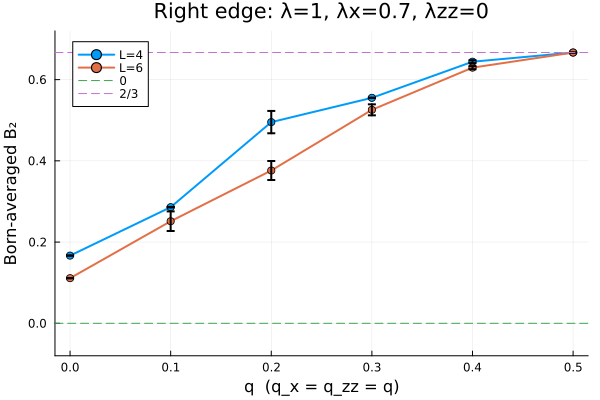

In [15]:

# ============================================================
# Plot proposal-averaged B2 versus q
# ============================================================

function plot_binder_scan(
    summary::DataFrame;
    title_suffix::AbstractString="",
)
    nrow(summary) > 0 || error("The summary table is empty.")

    p = plot(
        xlabel="q  (q_x = q_zz = q)",
        ylabel="Born-averaged B₂",
        title="Right edge: λ=1, λx=0.7, λzz=0" * title_suffix,
        legend=:best,
        ylims=(-0.08, 0.72),
    )

    for group in groupby(summary, :L)
        data = sort(DataFrame(group), :q)

        plot!(
            p,
            data.q,
            data.B2;
            yerror=data.B2_bootstrap_se,
            marker=:circle,
            linewidth=2,
            label="L=$(first(data.L))",
        )
    end

    hline!(p, [0.0]; linestyle=:dash, label="0")
    hline!(p, [2 / 3]; linestyle=:dash, label="2/3")

    return p
end

if nrow(active_scan.summary) > 0
    binder_plot = plot_binder_scan(active_scan.summary)
    display(binder_plot)
end


In [20]:

# ============================================================
# Quick and production configurations
# ============================================================

empty_scan = (
    summary=DataFrame(),
    trials=DataFrame(),
)

quick_scan = empty_scan

if RUN_QUICK_SCAN
    quick_scan = scan_right_edge(
        [8, 10],
        collect(0.0:0.10:0.50);
        ntrials=8,
        T_max_factor=2,
        maxdim=128,
        cutoff=1e-12,
        obs_maxdim_factor=4,
        obs_cutoff=1e-13,
        seed=11071,
        nboot=300,
        verbose=true,
    )

    display(quick_scan.summary)
end

production_scan = empty_scan

if RUN_PRODUCTION_SCAN
    # First use a coarse grid, then refine around the crossing.
    production_scan = scan_right_edge(
        [6, 8, 10, 12, 14, 16],
        collect(0.00:0.01:0.50);
        ntrials=300,
        T_max_factor=6,
        maxdim=256,
        cutoff=1e-12,
        obs_maxdim_factor=4,
        obs_cutoff=1e-14,
        seed=20260709,
        nboot=3000,
        verbose=true,
    )

    display(production_scan.summary)
end

active_scan =
    nrow(production_scan.summary) > 0 ?
    production_scan : quick_scan


[1/12] L=8, q=0.00000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[2/12] L=8, q=0.10000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[3/12] L=8, q=0.20000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[4/12] L=8, q=0.30000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[5/12] L=8, q=0.40000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[6/12] L=8, q=0.50000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[7/12] L=10, q=0.00000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[8/12] L=10, q=0.10000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[9/12] L=10, q=0.20000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[10/12] L=10, q=0.30000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[11/12] L=10, q=0.40000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[12/12] L=10, q=0.50000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q


Row,L,lambda,delta,lambda_x,lambda_zz,q,q_x,q_zz,boundary,T_max,ntrials,n_valid,seed,maxdim,cutoff,obs_maxdim,obs_cutoff,B2,B2_bootstrap_se,B2_ci_low,B2_ci_high,B2_trial_std,B2_ratio_of_mean_moments,M2_mean,M4_mean,purity_mean,purity_std,max_interphysical_linkdim,max_trace_error
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String,Int64,Int64,Int64,Int64,Int64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Float64
1,8,1.0,0.7,0.7,0.0,0.0,0.0,0.0,open,16,8,8,812071,128,1.0e-12,512,1.0e-13,0.0833333,3.96736e-16,0.0833333,0.0833333,1.13376e-15,0.0833333,0.125,0.0429688,1.0,5.64548e-16,1,2.22045e-16
2,8,1.0,0.7,0.7,0.0,0.1,0.1,0.1,open,16,8,8,813071,128,1.0e-12,512,1.0e-13,0.162827,0.00439377,0.15773,0.172284,0.0134019,0.162349,0.187743,0.0885749,0.23802,0.0257069,7,2.22045e-16
3,8,1.0,0.7,0.7,0.0,0.2,0.2,0.2,open,16,8,8,814071,128,1.0e-12,512,1.0e-13,0.313017,0.0183004,0.281907,0.344137,0.0534159,0.315313,0.32303,0.214337,0.0590577,0.0119273,8,2.22045e-16
4,8,1.0,0.7,0.7,0.0,0.3,0.3,0.3,open,16,8,8,815071,128,1.0e-12,512,1.0e-13,0.522197,0.0214665,0.484581,0.566019,0.0639974,0.529434,0.617003,0.537423,0.0174464,0.00412324,8,2.22045e-16
5,8,1.0,0.7,0.7,0.0,0.4,0.4,0.4,open,16,8,8,816071,128,1.0e-12,512,1.0e-13,0.622157,0.00593953,0.612152,0.635202,0.0182495,0.622932,0.854281,0.825549,0.00968993,0.000928517,7,2.22045e-16
6,8,1.0,0.7,0.7,0.0,0.5,0.5,0.5,open,16,8,8,817071,128,1.0e-12,512,1.0e-13,0.666667,4.06682e-16,0.666667,0.666667,7.32843e-16,0.666667,1.0,1.0,0.0078125,5.34032e-9,2,1.11022e-16
7,10,1.0,0.7,0.7,0.0,0.0,0.0,0.0,open,20,8,8,1018071,128,1.0e-12,512,1.0e-13,0.0666667,6.50104e-16,0.0666667,0.0666667,2.04521e-15,0.0666667,0.1,0.028,1.0,3.02596e-16,1,2.22045e-16
8,10,1.0,0.7,0.7,0.0,0.1,0.1,0.1,open,20,8,8,1019071,128,1.0e-12,512,1.0e-13,0.139341,0.004547,0.132052,0.148656,0.0131554,0.138645,0.156401,0.0632096,0.144201,0.0224258,8,2.22045e-16
9,10,1.0,0.7,0.7,0.0,0.2,0.2,0.2,open,20,8,8,1020071,128,1.0e-12,512,1.0e-13,0.296199,0.0342838,0.245053,0.37089,0.0995515,0.306489,0.2969,0.183398,0.0239161,0.00807112,8,2.22045e-16


(summary = 12×29 DataFrame
 Row │ L      lambda   delta    lambda_x  lambda_zz  q        q_x      q_zz    ⋯
     │ Int64  Float64  Float64  Float64   Float64    Float64  Float64  Float64 ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │     8      1.0      0.7       0.7        0.0      0.0      0.0      0.0 ⋯
   2 │     8      1.0      0.7       0.7        0.0      0.1      0.1      0.1
   3 │     8      1.0      0.7       0.7        0.0      0.2      0.2      0.2
   4 │     8      1.0      0.7       0.7        0.0      0.3      0.3      0.3
   5 │     8      1.0      0.7       0.7        0.0      0.4      0.4      0.4 ⋯
   6 │     8      1.0      0.7       0.7        0.0      0.5      0.5      0.5
   7 │    10      1.0      0.7       0.7        0.0      0.0      0.0      0.0
   8 │    10      1.0      0.7       0.7        0.0      0.1      0.1      0.1
   9 │    10      1.0      0.7       0.7        0.0      0.2      0.2      0.2 ⋯
  10 │    10 

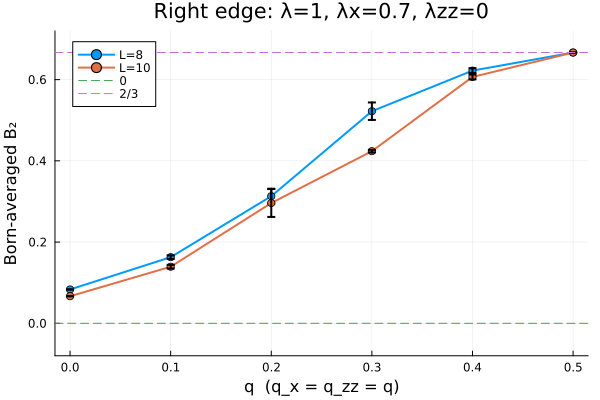

In [21]:

# ============================================================
# Plot proposal-averaged B2 versus q
# ============================================================

function plot_binder_scan(
    summary::DataFrame;
    title_suffix::AbstractString="",
)
    nrow(summary) > 0 || error("The summary table is empty.")

    p = plot(
        xlabel="q  (q_x = q_zz = q)",
        ylabel="Born-averaged B₂",
        title="Right edge: λ=1, λx=0.7, λzz=0" * title_suffix,
        legend=:best,
        ylims=(-0.08, 0.72),
    )

    for group in groupby(summary, :L)
        data = sort(DataFrame(group), :q)

        plot!(
            p,
            data.q,
            data.B2;
            yerror=data.B2_bootstrap_se,
            marker=:circle,
            linewidth=2,
            label="L=$(first(data.L))",
        )
    end

    hline!(p, [0.0]; linestyle=:dash, label="0")
    hline!(p, [2 / 3]; linestyle=:dash, label="2/3")

    return p
end

if nrow(active_scan.summary) > 0
    binder_plot = plot_binder_scan(active_scan.summary)
    display(binder_plot)
end


In [22]:

# ============================================================
# Quick and production configurations
# ============================================================

empty_scan = (
    summary=DataFrame(),
    trials=DataFrame(),
)

quick_scan = empty_scan

if RUN_QUICK_SCAN
    quick_scan = scan_right_edge(
        [12, 16],
        collect(0.0:0.10:0.50);
        ntrials=8,
        T_max_factor=2,
        maxdim=128,
        cutoff=1e-12,
        obs_maxdim_factor=4,
        obs_cutoff=1e-13,
        seed=11071,
        nboot=300,
        verbose=true,
    )

    display(quick_scan.summary)
end

production_scan = empty_scan

if RUN_PRODUCTION_SCAN
    # First use a coarse grid, then refine around the crossing.
    production_scan = scan_right_edge(
        [6, 8, 10, 12, 14, 16],
        collect(0.00:0.01:0.50);
        ntrials=300,
        T_max_factor=6,
        maxdim=256,
        cutoff=1e-12,
        obs_maxdim_factor=4,
        obs_cutoff=1e-14,
        seed=20260709,
        nboot=3000,
        verbose=true,
    )

    display(production_scan.summary)
end

active_scan =
    nrow(production_scan.summary) > 0 ?
    production_scan : quick_scan


[1/12] L=12, q=0.00000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[2/12] L=12, q=0.10000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[3/12] L=12, q=0.20000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[4/12] L=12, q=0.30000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[5/12] L=12, q=0.40000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[6/12] L=12, q=0.50000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[7/12] L=16, q=0.00000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[8/12] L=16, q=0.10000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[9/12] L=16, q=0.20000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[10/12] L=16, q=0.30000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[11/12] L=16, q=0.40000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q
[12/12] L=16, q=0.50000, lambda_x=0.7, lambda_zz=0, q_x=q_zz=q


Row,L,lambda,delta,lambda_x,lambda_zz,q,q_x,q_zz,boundary,T_max,ntrials,n_valid,seed,maxdim,cutoff,obs_maxdim,obs_cutoff,B2,B2_bootstrap_se,B2_ci_low,B2_ci_high,B2_trial_std,B2_ratio_of_mean_moments,M2_mean,M4_mean,purity_mean,purity_std,max_interphysical_linkdim,max_trace_error
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String,Int64,Int64,Int64,Int64,Int64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Float64
1,12,1.0,0.7,0.7,0.0,0.0,0.0,0.0,open,24,8,8,1212071,128,1.0e-12,512,1.0e-13,0.0555556,8.19367e-16,0.0555556,0.0555556,2.46831e-15,0.0555556,0.0833333,0.0196759,1.0,3.14018e-16,1,2.22045e-16
2,12,1.0,0.7,0.7,0.0,0.1,0.1,0.1,open,24,8,8,1213071,128,1.0e-12,512,1.0e-13,0.12805,0.0110534,0.111065,0.157436,0.0333571,0.125804,0.13574,0.0483219,0.0897977,0.0247845,8,2.22045e-16
3,12,1.0,0.7,0.7,0.0,0.2,0.2,0.2,open,24,8,8,1214071,128,1.0e-12,512,1.0e-13,0.210844,0.00578412,0.203281,0.223238,0.0167719,0.210178,0.21547,0.110008,0.0132405,0.00176254,9,2.22045e-16
4,12,1.0,0.7,0.7,0.0,0.3,0.3,0.3,open,24,8,8,1215071,128,1.0e-12,512,1.0e-13,0.502062,0.0324657,0.440021,0.558113,0.100595,0.517108,0.564216,0.461171,0.00160444,0.000663634,8,2.22045e-16
5,12,1.0,0.7,0.7,0.0,0.4,0.4,0.4,open,24,8,8,1216071,128,1.0e-12,512,1.0e-13,0.595823,0.00637061,0.58707,0.610084,0.0203829,0.596786,0.778494,0.733107,0.00071452,5.22139e-5,8,2.22045e-16
6,12,1.0,0.7,0.7,0.0,0.5,0.5,0.5,open,24,8,8,1217071,128,1.0e-12,512,1.0e-13,0.666667,3.86144e-16,0.666667,0.666667,9.34549e-16,0.666667,1.0,1.0,0.000488248,9.12305e-8,2,2.22045e-16
7,16,1.0,0.7,0.7,0.0,0.0,0.0,0.0,open,32,8,8,1618071,128,1.0e-12,512,1.0e-13,0.0416667,1.30841e-15,0.0416667,0.0416667,3.73761e-15,0.0416667,0.0625,0.0112305,1.0,3.86875e-16,1,2.22045e-16
8,16,1.0,0.7,0.7,0.0,0.1,0.1,0.1,open,32,8,8,1619071,128,1.0e-12,512,1.0e-13,0.0858411,0.00182629,0.0826526,0.0893827,0.00581656,0.0851867,0.0974103,0.0260414,0.0449148,0.00789151,8,2.22045e-16
9,16,1.0,0.7,0.7,0.0,0.2,0.2,0.2,open,32,8,8,1620071,128,1.0e-12,512,1.0e-13,0.194296,0.0170553,0.166285,0.227471,0.0546386,0.193067,0.182666,0.0807745,0.00228637,0.000727411,10,2.22045e-16


(summary = 12×29 DataFrame
 Row │ L      lambda   delta    lambda_x  lambda_zz  q        q_x      q_zz    ⋯
     │ Int64  Float64  Float64  Float64   Float64    Float64  Float64  Float64 ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │    12      1.0      0.7       0.7        0.0      0.0      0.0      0.0 ⋯
   2 │    12      1.0      0.7       0.7        0.0      0.1      0.1      0.1
   3 │    12      1.0      0.7       0.7        0.0      0.2      0.2      0.2
   4 │    12      1.0      0.7       0.7        0.0      0.3      0.3      0.3
   5 │    12      1.0      0.7       0.7        0.0      0.4      0.4      0.4 ⋯
   6 │    12      1.0      0.7       0.7        0.0      0.5      0.5      0.5
   7 │    16      1.0      0.7       0.7        0.0      0.0      0.0      0.0
   8 │    16      1.0      0.7       0.7        0.0      0.1      0.1      0.1
   9 │    16      1.0      0.7       0.7        0.0      0.2      0.2      0.2 ⋯
  10 │    16 

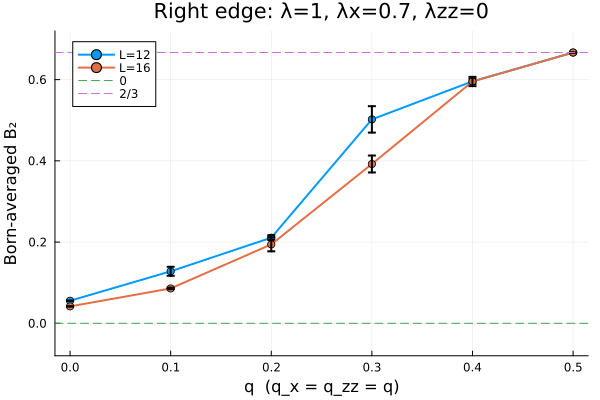

In [23]:

# ============================================================
# Plot proposal-averaged B2 versus q
# ============================================================

function plot_binder_scan(
    summary::DataFrame;
    title_suffix::AbstractString="",
)
    nrow(summary) > 0 || error("The summary table is empty.")

    p = plot(
        xlabel="q  (q_x = q_zz = q)",
        ylabel="Born-averaged B₂",
        title="Right edge: λ=1, λx=0.7, λzz=0" * title_suffix,
        legend=:best,
        ylims=(-0.08, 0.72),
    )

    for group in groupby(summary, :L)
        data = sort(DataFrame(group), :q)

        plot!(
            p,
            data.q,
            data.B2;
            yerror=data.B2_bootstrap_se,
            marker=:circle,
            linewidth=2,
            label="L=$(first(data.L))",
        )
    end

    hline!(p, [0.0]; linestyle=:dash, label="0")
    hline!(p, [2 / 3]; linestyle=:dash, label="2/3")

    return p
end

if nrow(active_scan.summary) > 0
    binder_plot = plot_binder_scan(active_scan.summary)
    display(binder_plot)
end


In [16]:

# ============================================================
# Pairwise finite-size crossing estimates
# ============================================================

function pairwise_linear_crossings(
    summary::DataFrame,
    L1::Int,
    L2::Int,
)
    first_size = select(
        filter(:L => ==(L1), summary),
        :q,
        :B2 => :B2_1,
    )

    second_size = select(
        filter(:L => ==(L2), summary),
        :q,
        :B2 => :B2_2,
    )

    joined = sort(
        innerjoin(first_size, second_size; on=:q),
        :q,
    )

    nrow(joined) >= 2 || return Float64[]

    crossings = Float64[]

    for i in 1:(nrow(joined) - 1)
        x1, x2 = joined.q[i], joined.q[i + 1]
        d1 = joined.B2_1[i] - joined.B2_2[i]
        d2 = joined.B2_1[i + 1] - joined.B2_2[i + 1]

        if d1 == 0
            push!(crossings, x1)
        elseif d1 * d2 < 0
            crossing =
                x1 - d1 * (x2 - x1) / (d2 - d1)
            push!(crossings, crossing)
        end
    end

    return unique(crossings)
end

function crossing_summary(summary::DataFrame)
    sizes = sort(unique(summary.L))
    rows = NamedTuple[]

    for i in 1:(length(sizes) - 1)
        L1, L2 = sizes[i], sizes[i + 1]
        crossings =
            pairwise_linear_crossings(summary, L1, L2)

        if isempty(crossings)
            push!(rows, (
                L1=L1,
                L2=L2,
                crossing_index=0,
                q_crossing=NaN,
            ))
        else
            for (index, crossing) in enumerate(crossings)
                push!(rows, (
                    L1=L1,
                    L2=L2,
                    crossing_index=index,
                    q_crossing=crossing,
                ))
            end
        end
    end

    return DataFrame(rows)
end

if nrow(active_scan.summary) > 0
    crossings = crossing_summary(active_scan.summary)
    display(crossings)
end


Row,L1,L2,crossing_index,q_crossing
,Int64,Int64,Int64,Float64
1,4,6,1,0.5



## Critical scaling scaffold

Once a stable crossing estimate \(q_c\) is available, test the finite-size form

\[
\overline{B_2}(q,L)
=
F\!\left[(q-q_c)L^{1/\nu}\right].
\]

The proposal does **not** assume that \(B_2\) and \(S_R\) have the same scaling
function or exponent. Their transition locations should be compared first;
their critical scaling should then be studied independently.


In [17]:

# ============================================================
# Scaling-collapse plot for user-supplied q_c and nu
# ============================================================

function plot_scaling_collapse(
    summary::DataFrame;
    q_c::Float64,
    nu::Float64,
)
    nrow(summary) > 0 || error("The summary table is empty.")
    nu > 0 || error("nu must be positive.")

    p = plot(
        xlabel="(q - q_c) L^(1/nu)",
        ylabel="Born-averaged B₂",
        title=@sprintf(
            "B₂ scaling collapse: q_c=%.5f, ν=%.4f",
            q_c,
            nu,
        ),
        legend=:best,
    )

    for group in groupby(summary, :L)
        data = sort(DataFrame(group), :q)
        L = first(data.L)
        scaled_x = (data.q .- q_c) .* L^(1 / nu)

        plot!(
            p,
            scaled_x,
            data.B2;
            yerror=data.B2_bootstrap_se,
            marker=:circle,
            linewidth=2,
            label="L=$L",
        )
    end

    return p
end

# After obtaining a stable crossing and exponent estimate:
# display(plot_scaling_collapse(active_scan.summary; q_c=0.30, nu=1.5))


plot_scaling_collapse (generic function with 1 method)

In [18]:

# ============================================================
# Convergence checks
# ============================================================

function convergence_table(
    L::Int,
    q::Float64;
    T_factors=(2, 4, 6),
    maxdims=(128, 256, 512),
    ntrials::Int=60,
    seed::Int=314159,
)
    rows = NamedTuple[]

    for T_factor in T_factors
        for maxdim in maxdims
            result = run_right_edge_point(
                L,
                q;
                ntrials=ntrials,
                T_max=T_factor * L,
                maxdim=maxdim,
                cutoff=DYN_CUTOFF,
                obs_maxdim=OBS_MAXDIM_FACTOR * maxdim,
                obs_cutoff=OBS_CUTOFF,
                seed=seed + 1000 * T_factor + maxdim,
                nboot=500,
            )

            push!(rows, (
                L=L,
                q=q,
                T_max=T_factor * L,
                maxdim=maxdim,
                B2=result.summary.B2,
                B2_se=result.summary.B2_bootstrap_se,
                B2_ratio_of_mean_moments=
                    result.summary.B2_ratio_of_mean_moments,
                M2_mean=result.summary.M2_mean,
                M4_mean=result.summary.M4_mean,
                purity_mean=result.summary.purity_mean,
                max_trace_error=result.summary.max_trace_error,
            ))
        end
    end

    return DataFrame(rows)
end

# Example near a candidate crossing:
# display(convergence_table(10, 0.30; ntrials=80))


convergence_table (generic function with 1 method)

In [19]:

# ============================================================
# Diagnostics and export
# ============================================================

function diagnose_scan(scan)
    summary = scan.summary
    nrow(summary) > 0 || error("The scan is empty.")

    println(
        "Maximum trace error: ",
        maximum(summary.max_trace_error),
    )

    println(
        "Maximum inter-physical-site link dimension: ",
        maximum(summary.max_interphysical_linkdim),
    )

    println(
        "Maximum |proposal B2 - ratio-of-mean-moments diagnostic|: ",
        maximum(
            abs.(
                summary.B2 .-
                summary.B2_ratio_of_mean_moments
            )
        ),
    )

    if any(summary.q_x .!= summary.q_zz)
        error("Proposal violation: q_x and q_zz are not equal.")
    end

    if any(summary.q .> 0.5) || any(summary.q .< 0.0)
        error("Proposal violation: q is outside [0, 1/2].")
    end

    println("Parameterization checks passed.")
end

function export_scan(
    scan;
    prefix::AbstractString="right_edge_proposal_B2",
)
    nrow(scan.summary) > 0 || error("The scan is empty.")

    stamp = Dates.format(now(), "yyyymmdd_HHMMSS")
    summary_path = "$(prefix)_summary_$(stamp).csv"
    trials_path = "$(prefix)_trials_$(stamp).csv"
    plot_path = "$(prefix)_$(stamp).png"

    CSV.write(summary_path, scan.summary)
    CSV.write(trials_path, scan.trials)

    p = plot_binder_scan(scan.summary)
    savefig(p, plot_path)

    println("Saved: ", summary_path)
    println("Saved: ", trials_path)
    println("Saved: ", plot_path)

    return (
        summary=summary_path,
        trials=trials_path,
        plot=plot_path,
    )
end

if nrow(active_scan.summary) > 0
    diagnose_scan(active_scan)
end

# Example:
# export_scan(active_scan)


Maximum trace error: 3.3306690738754696e-16
Maximum inter-physical-site link dimension: 8
Maximum |proposal B2 - ratio-of-mean-moments diagnostic|: 0.011340940584541048
Parameterization checks passed.



## Research-proposal checklist

Before calling a crossing the right boundary:

1. **Correct slice**
   \[
   \lambda=1,\quad \lambda_x=0.7,\quad \lambda_{zz}=0,
   \quad q_x=q_{zz}=q.
   \]

2. **Correct scan range**  
   Use \(0\le q\le 1/2\), refining the grid around the crossing.

3. **Correct nonlinear observable**  
   Use \(Z_iZ_i'\) replica-overlap correlations, not a bra-only magnetization.

4. **Correct averaging order**  
   Compute \(B_2(m)\) for each Born-sampled measurement trajectory and then
   average \(B_2(m)\).

5. **Steady state**  
   Increase \(T/L\) until \(B_2\), \(M_2\), \(M_4\), and purity stop drifting.

6. **MPS convergence**  
   Increase `maxdim`, tighten `cutoff`, and evaluate observables with a larger
   bond dimension than the dynamics.

7. **Finite-size evidence**  
   Require stable crossings across multiple adjacent size pairs; do not identify
   a transition from a single curve.

8. **Proposal comparison**  
   Compare the final \(B_2\) boundary with the \(S_R\) boundary from a separate
   reference-qubit calculation.

9. **Criticality**  
   After locating \(q_c\), study the \(B_2\) scaling collapse without assuming
   that its exponent must equal the \(S_R\) exponent.

10. **Next proposal stages**  
    Repeat away from the right edge to map the full strong-to-weak boundary,
    then compare nonlinear observables and later test unitary perturbations.
